In [1]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

documents = [
    "The sun is shining today.",
    "The weather is good, the sun is great.",
    "A sunny day is a wonderful day."
]

print("--- Raw Text Documents ---")
for i, doc in enumerate(documents):
    print(f"Doc {i+1}: {doc}")

--- Raw Text Documents ---
Doc 1: The sun is shining today.
Doc 2: The weather is good, the sun is great.
Doc 3: A sunny day is a wonderful day.


In [2]:
vectorizer = CountVectorizer()

X_text = vectorizer.fit_transform(documents)

feature_names = vectorizer.get_feature_names_out()
text_matrix = X_text.toarray()

print("Vocabulary:")
print(feature_names)

print("\nShape:")
print(text_matrix.shape)

print("\nDocument-Term Matrix:")
print(text_matrix)

Vocabulary:
['day' 'good' 'great' 'is' 'shining' 'sun' 'sunny' 'the' 'today' 'weather'
 'wonderful']

Shape:
(3, 11)

Document-Term Matrix:
[[0 0 0 1 1 1 0 1 1 0 0]
 [0 1 1 2 0 1 0 2 0 1 0]
 [2 0 0 1 0 0 1 0 0 0 1]]


In [3]:
print("Feature Names:")
for i, word in enumerate(feature_names):
    print(f"{i}: {word}")

Feature Names:
0: day
1: good
2: great
3: is
4: shining
5: sun
6: sunny
7: the
8: today
9: weather
10: wonderful


In [4]:
print("Document 1:", documents[0])
print("Vector 1:", text_matrix[0])

print("\nDocument 2:", documents[1])
print("Vector 2:", text_matrix[1])

print("\nDocument 3:", documents[2])
print("Vector 3:", text_matrix[2])

Document 1: The sun is shining today.
Vector 1: [0 0 0 1 1 1 0 1 1 0 0]

Document 2: The weather is good, the sun is great.
Vector 2: [0 1 1 2 0 1 0 2 0 1 0]

Document 3: A sunny day is a wonderful day.
Vector 3: [2 0 0 1 0 0 1 0 0 0 1]


Question 1
What does each column in the resulting matrix represent?

Each column in the resulting matrix represents one unique word (feature) from the vocabulary.
The value in each cell shows how many times that word occurs in the corresponding document.

Question 2:
“In this specific numerical matrix, what is the machine-understandable format?”

The machine-understandable format is a numerical Document-Term Matrix. Each document is represented as a fixed-length vector of numbers,
where each number shows the count of a specific vocabulary word in that document.

Question 3
How is this format an oversimplification of the original text data? (Consider what information has been lost.)

The Bag-of-Words format is an oversimplification because it ignores grammar and word order. It only records how many times each word occurs.
As a result, information such as the meaning created by word order, sentence structure, and the relationship between words is lost.

In [7]:
import numpy as np
from PIL import Image
import os

image_file_path = r"D:\ai-lab-portfolio\lena.jfif"

original_image = None

if image_file_path and os.path.exists(image_file_path):
    try:
        original_image = Image.open(image_file_path)
        print(f"--- Loaded Image from File: {image_file_path} ---")
    except Exception as e:
        print(f"Error loading image from {image_file_path}: {e}")
        dummy = np.random.randint(0, 256, size=(100, 100, 3), dtype=np.uint8)
        original_image = Image.fromarray(dummy, 'RGB')
        print("--- Created Dummy Image (100x100 RGB) ---")
else:
    print("No valid image file path provided or file not found.")
    dummy = np.random.randint(0, 256, size=(100, 100, 3), dtype=np.uint8)
    original_image = Image.fromarray(dummy, 'RGB')
    print("--- Created Dummy Image (100x100 RGB) ---")

original_image = original_image.convert('RGB')
original_image_array = np.array(original_image)

h, w, c = original_image_array.shape

print(f"Original Image Size (H, W, Channels): {original_image_array.shape}")
print(f"Total Features (Pixels) in RGB: {h * w * c}")

--- Loaded Image from File: D:\ai-lab-portfolio\lena.jfif ---
Original Image Size (H, W, Channels): (350, 465, 3)
Total Features (Pixels) in RGB: 488250


In [8]:
grayscale_image = original_image.convert('L')
grayscale_array = np.array(grayscale_image)

print("--- Grayscale Conversion (Feature Reduction) ---")
print(f"Grayscale Image Size (H, W): {grayscale_array.shape}")
print(f"Total Features (Pixels) after Grayscale: {grayscale_array.size}")
print()
print(f"Reduction factor: {(h * w * c) / grayscale_array.size:.0f}x fewer features")

--- Grayscale Conversion (Feature Reduction) ---
Grayscale Image Size (H, W): (350, 465)
Total Features (Pixels) after Grayscale: 162750

Reduction factor: 3x fewer features


In [9]:
flattened_features = grayscale_array.flatten()

print("--- Pixel Flattening (Vectorization) ---")
print(f"Flattened Feature Vector Shape: {flattened_features.shape}")
print()
print("First 10 Features (Pixel Values) in Machine Understandable Format:")
print(flattened_features[:10])
print()
print(f"Data Type of Final Features: {flattened_features.dtype}")

--- Pixel Flattening (Vectorization) ---
Flattened Feature Vector Shape: (162750,)

First 10 Features (Pixel Values) in Machine Understandable Format:
[26 40 55 58 49 40 38 41 55 62]

Data Type of Final Features: uint8


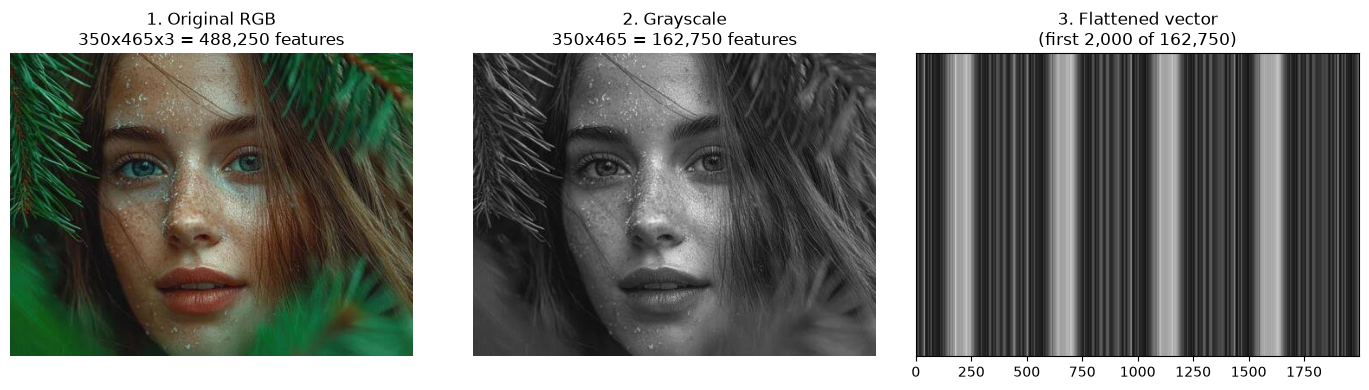

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].imshow(original_image)
axes[0].set_title(f"1. Original RGB\n{h}x{w}x{c} = {h*w*c:,} features")
axes[0].axis('off')

axes[1].imshow(grayscale_image, cmap='gray')
axes[1].set_title(f"2. Grayscale\n{h}x{w} = {h*w:,} features")
axes[1].axis('off')

axes[2].imshow(flattened_features[:2000].reshape(1, -1), cmap='gray', aspect='auto')
axes[2].set_title(f"3. Flattened vector\n(first 2,000 of {flattened_features.size:,})")
axes[2].set_yticks([])

plt.tight_layout()
plt.show()

Question 1
Explain how grayscale conversion acts as a simple feature engineering technique in the context of machine learning.

Grayscale conversion is a simple feature engineering technique because it reduces an RGB image from three color channels to one intensity channel.
This decreases the number of features while retaining brightness information,making the image data simpler and easier for a machine learning model
to process.

Question 2
If the loaded image had dimensions \(H \times W\) pixels, what is the length of the final flattened vector after grayscale conversion?

After grayscale conversion, the image has one pixel value for each position. Therefore, the length of the final flattened vector is H × W.

Question 3
Why is flattening necessary before feeding the data to a simple model such as Logistic Regression or a Support Vector Machine?

Flattening converts the two-dimensional pixel matrix into a one-dimensional feature vector.This gives each image a fixed-length numerical 
representation that simple machine learning models such as Logistic Regression and Support Vector Machines can accept as input.

Question 4
Why is resizing all images to a consistent size (e.g. \(64\times64\)) useful when the model must process many different images?

Resizing all images to a consistent size ensures that every image produces the same number of features after grayscale conversion and flattening.
This gives the machine learning model a fixed-size input for all images.

In [11]:
vectorizer_ngram = CountVectorizer(ngram_range=(1, 2))

X_ngram = vectorizer_ngram.fit_transform(documents)

ngram_features = vectorizer_ngram.get_feature_names_out()

print("Number of features:", len(ngram_features))
print("\nFeatures:")
print(ngram_features)

Number of features: 24

Features:
['day' 'day is' 'good' 'good the' 'great' 'is' 'is good' 'is great'
 'is shining' 'is wonderful' 'shining' 'shining today' 'sun' 'sun is'
 'sunny' 'sunny day' 'the' 'the sun' 'the weather' 'today' 'weather'
 'weather is' 'wonderful' 'wonderful day']


Using `ngram_range=(1,2)` includes both individual words (unigrams) and consecutive two-word combinations (bigrams). Therefore,
the vocabulary grows from 11 features to 24 features because the model now represents relationships between adjacent words as additional features.

In [12]:
documents_ex2 = documents + [
    "sun sun sun sun sun"
]

print("Documents:")
for i, doc in enumerate(documents_ex2):
    print(f"Doc {i+1}: {doc}")

Documents:
Doc 1: The sun is shining today.
Doc 2: The weather is good, the sun is great.
Doc 3: A sunny day is a wonderful day.
Doc 4: sun sun sun sun sun


In [13]:
vectorizer_ex2 = CountVectorizer()
X_ex2 = vectorizer_ex2.fit_transform(documents_ex2)

features_ex2 = vectorizer_ex2.get_feature_names_out()
matrix_ex2 = X_ex2.toarray()

print("Vocabulary:")
print(features_ex2)

print("\nShape:")
print(matrix_ex2.shape)

print("\nDocument-Term Matrix:")
print(matrix_ex2)

Vocabulary:
['day' 'good' 'great' 'is' 'shining' 'sun' 'sunny' 'the' 'today' 'weather'
 'wonderful']

Shape:
(4, 11)

Document-Term Matrix:
[[0 0 0 1 1 1 0 1 1 0 0]
 [0 1 1 2 0 1 0 2 0 1 0]
 [2 0 0 1 0 0 1 0 0 0 1]
 [0 0 0 0 0 5 0 0 0 0 0]]


### Exercise 2 Explanation

The fourth document increases the Document-Term Matrix from 3 × 11 to 4 × 11 because one more document has been added. The vocabulary remains the same because the fourth document only contains the word "sun", which was already present in the vocabulary.

In the fourth row, the value for "sun" is 5 because the word appears five times. Raw word counts can favour longer documents because longer documents naturally have more opportunities to contain and repeat words. Therefore, a word may receive a higher count simply because the document is longer, not necessarily because the word is more important.

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [15]:
tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(documents_ex2)

tfidf_features = tfidf_vectorizer.get_feature_names_out()
tfidf_matrix = X_tfidf.toarray()

print("Vocabulary:")
print(tfidf_features)

print("\nShape:")
print(tfidf_matrix.shape)

print("\nTF-IDF Matrix:")
print(tfidf_matrix)

Vocabulary:
['day' 'good' 'great' 'is' 'shining' 'sun' 'sunny' 'the' 'today' 'weather'
 'wonderful']

Shape:
(4, 11)

TF-IDF Matrix:
[[0.         0.         0.         0.34432086 0.53944516 0.34432086
  0.         0.42530476 0.53944516 0.         0.        ]
 [0.         0.36457953 0.36457953 0.46541278 0.         0.23270639
  0.         0.57487737 0.         0.36457953 0.        ]
 [0.79011212 0.         0.         0.25215917 0.         0.
  0.39505606 0.         0.         0.         0.39505606]
 [0.         0.         0.         0.         0.         1.
  0.         0.         0.         0.         0.        ]]


### Exercise 3 Explanation

TF-IDF assigns weights to words based on their importance across the documents rather than using only raw word counts. In the fourth document, the word "sun" appears five times, but its TF-IDF value is normalized to 1.0 in this example. This shows that TF-IDF produces weighted numerical features instead of directly using raw frequency counts.

In [16]:
print("Sparse matrix type:")
print(type(X_ex2))

print("\nDense matrix type:")
print(type(matrix_ex2))

print("\nSparse matrix non-zero values:")
print(X_ex2.nnz)

print("\nTotal values in dense matrix:")
print(matrix_ex2.size)

Sparse matrix type:
<class 'scipy.sparse._csr.csr_matrix'>

Dense matrix type:
<class 'numpy.ndarray'>

Sparse matrix non-zero values:
16

Total values in dense matrix:
44


### Exercise 4 Explanation

A sparse matrix is memory-efficient because it mainly stores the non-zero values and their positions instead of treating every zero value as a 
meaningful stored value.In this example, the matrix contains 44 total positions but only 16 non-zero values. Therefore, sparse matrices are useful for 
text features because Document-Term Matrices often contain many zero values.

# Home Assignment — Image Dataset Construction

In [18]:
from PIL import Image
import os

dataset_path = r"D:\ai-lab-portfolio\lab03\dataset"

for class_name in ["class1", "class2"]:
    class_path = os.path.join(dataset_path, class_name)

    print(f"\n{class_name}:")
    
    for filename in sorted(os.listdir(class_path)):
        file_path = os.path.join(class_path, filename)
        
        try:
            with Image.open(file_path) as img:
                print(f"{filename} -> {img.format}, {img.size}")
        except Exception as e:
            print(f"{filename} -> ERROR: {e}")


class1:
i1.webp -> WEBP, (2000, 1333)
i10.jfif -> JPEG, (365, 547)
i2.jpg -> JPEG, (465, 350)
i3.jfif -> JPEG, (547, 365)
i4.jfif -> JPEG, (480, 638)
i5.jfif -> JPEG, (678, 452)
i6.jfif -> JPEG, (678, 452)
i7.jfif -> JPEG, (576, 384)
i8.jfif -> JPEG, (547, 365)
i9.jfif -> JPEG, (576, 384)

class2:
i1.avif -> AVIF, (600, 900)
i10.jpg -> JPEG, (4016, 6016)
i2.jpg -> JPEG, (1909, 3393)
i3.jpg -> JPEG, (3303, 4955)
i4.jpg -> JPEG, (4000, 6000)
i5.jpg -> JPEG, (4800, 4000)
i6.jpg -> JPEG, (5760, 3840)
i7.jpg -> JPEG, (3308, 4405)
i8.jpg -> JPEG, (3456, 5184)
i9.jpg -> JPEG, (4058, 6086)


In [19]:
from PIL import Image
import numpy as np

def image_to_features(path, size=(64, 64)):
    image = Image.open(path)
    image = image.convert('L')
    image = image.resize(size)
    image_array = np.array(image)
    features = image_array.flatten()
    return features

print("Function created successfully.")

Function created successfully.


In [20]:

test_images = [
    r"D:\ai-lab-portfolio\lena.jfif",
    r"D:\ai-lab-portfolio\lab03\dataset\class1\i1.webp",
    r"D:\ai-lab-portfolio\lab03\dataset\class2\i2.jpg"
]

for path in test_images:
    features = image_to_features(path, size=(64, 64))
    print(os.path.basename(path), "-> Vector shape:", features.shape)

lena.jfif -> Vector shape: (4096,)
i1.webp -> Vector shape: (4096,)
i2.jpg -> Vector shape: (4096,)


In [21]:

import os
import numpy as np
from glob import glob

CLASS_DIRS = {
    0: r"D:\ai-lab-portfolio\lab03\dataset\class1",
    1: r"D:\ai-lab-portfolio\lab03\dataset\class2"
}

SIZE = (64, 64)
X_list, y_list = [], []

for label, folder in CLASS_DIRS.items():
    paths = sorted(glob(os.path.join(folder, "*")))

    for path in paths:
        try:
            features = image_to_features(path, size=SIZE)
            X_list.append(features)
            y_list.append(label)
        except Exception as e:
            print(f"[SKIP] {path} -> {e}")

if X_list:
    X = np.vstack(X_list)
    y = np.array(y_list)

    save_path = r"D:\ai-lab-portfolio\lab03\dataset.npz"
    np.savez(save_path, X=X, y=y)

    print("X shape:", X.shape)
    print("y shape:", y.shape)
    print("Samples:", X.shape[0])
    print("Features per sample:", X.shape[1])
    print("Samples per feature:", round(X.shape[0] / X.shape[1], 4))
    print("Saved to:", save_path)
else:
    print("No images found. Please check the folder paths.")

X shape: (20, 4096)
y shape: (20,)
Samples: 20
Features per sample: 4096
Samples per feature: 0.0049
Saved to: D:\ai-lab-portfolio\lab03\dataset.npz


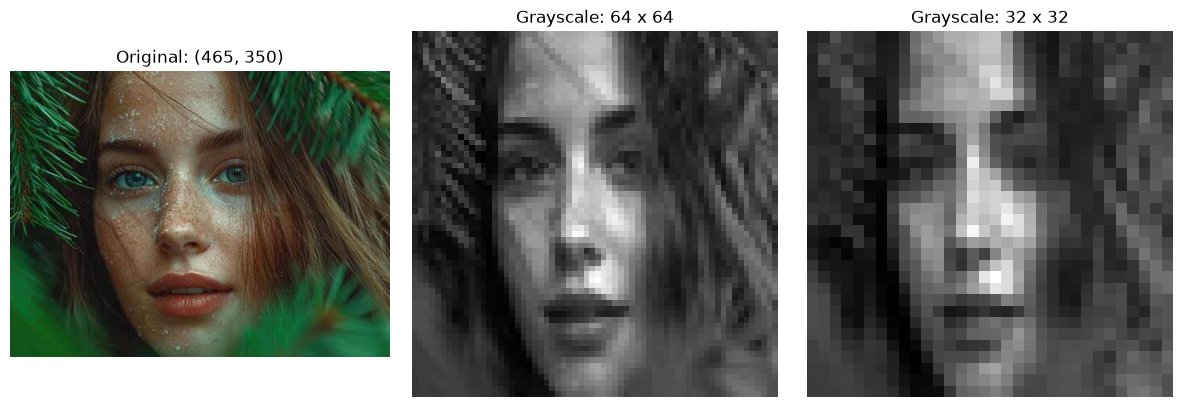

64x64 vector length: 4096
32x32 vector length: 1024


In [22]:

from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

image_path = r"D:\ai-lab-portfolio\lena.jfif"

# Load original image
original = Image.open(image_path).convert("RGB")

# Resize to two different sizes
image_64 = original.resize((64, 64)).convert("L")
image_32 = original.resize((32, 32)).convert("L")

# Flatten into feature vectors
vector_64 = np.array(image_64).flatten()
vector_32 = np.array(image_32).flatten()

# Display all three images
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(original)
plt.title(f"Original: {original.size}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(image_64, cmap="gray")
plt.title("Grayscale: 64 x 64")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(image_32, cmap="gray")
plt.title("Grayscale: 32 x 32")
plt.axis("off")

plt.tight_layout()
plt.show()

print("64x64 vector length:", len(vector_64))
print("32x32 vector length:", len(vector_32))

**Exercise 3 — Image Resizing**

Resizing an image to 64×64 produces 4,096 grayscale pixel features,
while resizing it to 32×32 produces 1,024 features. The smaller image uses fewer features
and requires less storage, but fine details, textures, and small objects become 
harder to distinguish.


In [24]:
from image_utils import image_to_features

test_features = image_to_features(
    r"D:\ai-lab-portfolio\lena.jfif"
)

print("Feature shape:", test_features.shape)

Feature shape: (4096,)
